Đang đọc dữ liệu và vẽ biểu đồ...


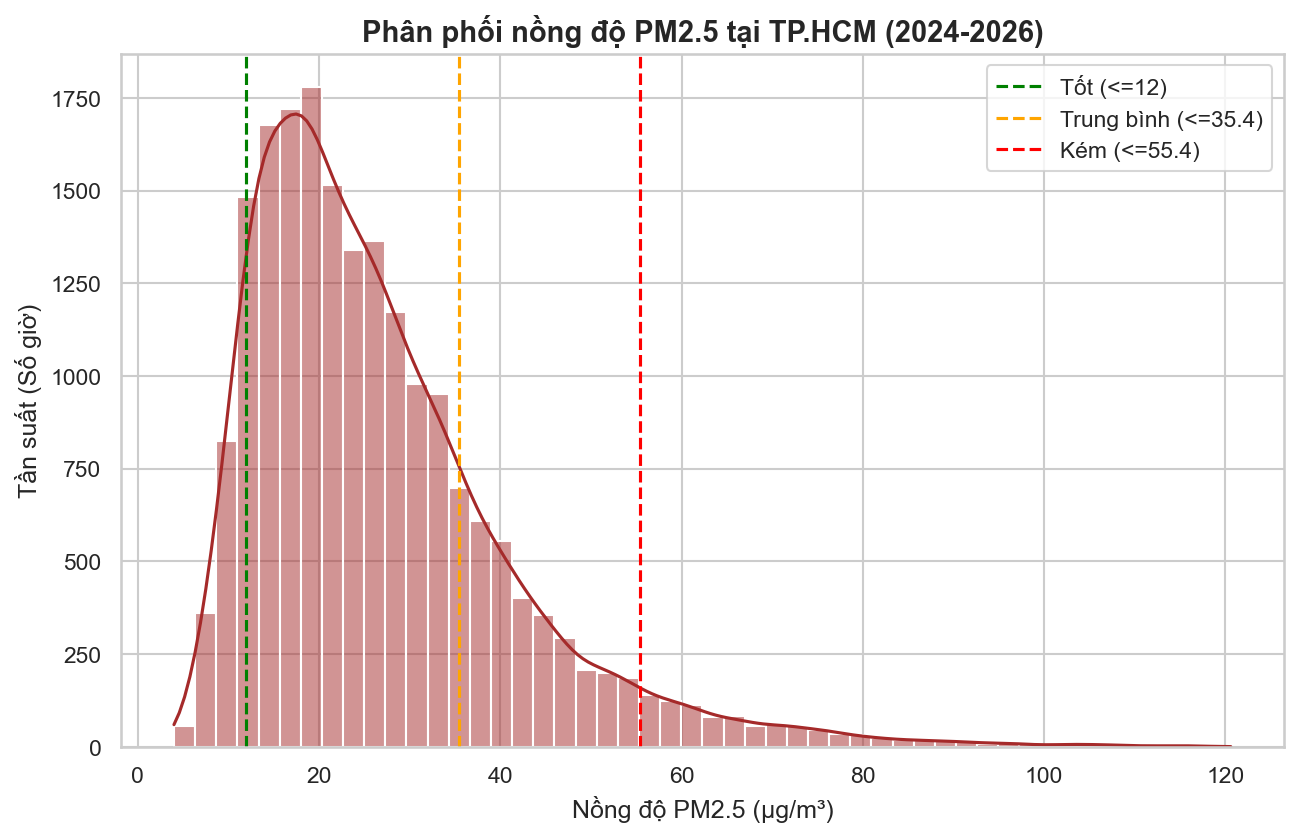

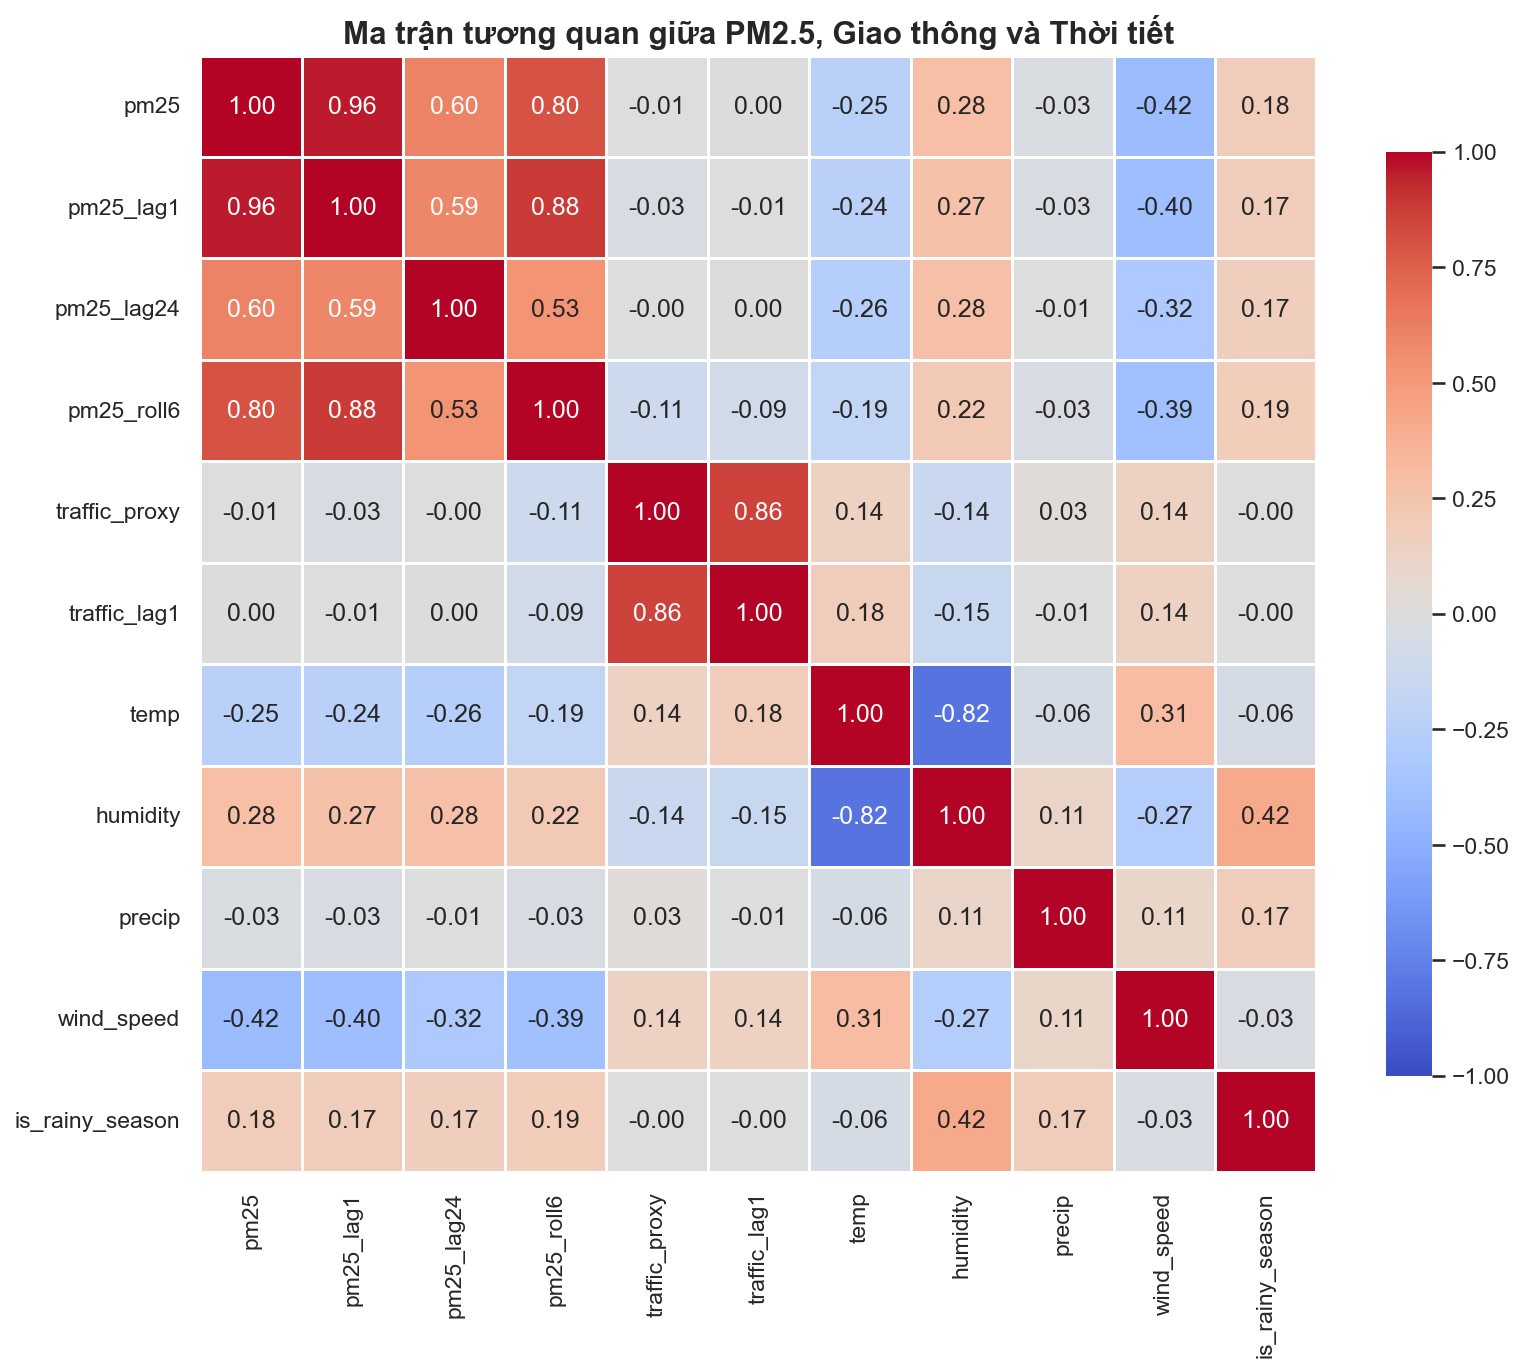

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập đường dẫn
PATH_INPUT = "../data/03_processed/pm25_features_ready.csv"
DIR_FIGURES = "../reports/figures/"

# Đảm bảo thư mục lưu ảnh tồn tại
os.makedirs(DIR_FIGURES, exist_ok=True)

# Cài đặt phong cách vẽ biểu đồ cho đẹp
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150 # Tăng độ nét của ảnh

print("Đang đọc dữ liệu và vẽ biểu đồ...")

try:
    df = pd.read_csv(PATH_INPUT)

    # BIỂU ĐỒ 1: Phân phối của biến mục tiêu (PM2.5)
    plt.figure(figsize=(10, 6))
    sns.histplot(df['pm25'], bins=50, kde=True, color='brown')
    
    # Thêm các vạch cảnh báo chất lượng không khí (AQI)
    plt.axvline(x=12, color='green', linestyle='--', label='Tốt (<=12)')
    plt.axvline(x=35.4, color='orange', linestyle='--', label='Trung bình (<=35.4)')
    plt.axvline(x=55.4, color='red', linestyle='--', label='Kém (<=55.4)')
    
    plt.title('Phân phối nồng độ PM2.5 tại TP.HCM (2024-2026)', fontsize=14, fontweight='bold')
    plt.xlabel('Nồng độ PM2.5 (µg/m³)')
    plt.ylabel('Tần suất (Số giờ)')
    plt.legend()
    
    # Lưu ảnh 1
    path_fig1 = os.path.join(DIR_FIGURES, "01_pm25_distribution.png")
    plt.savefig(path_fig1, bbox_inches='tight')
    plt.show()

    # BIỂU ĐỒ 2: Ma trận tương quan (Correlation Heatmap)
    # Chỉ chọn các biến quan trọng để đưa vào Heatmap (tránh bị rối)
    cols_to_corr = [
        'pm25', 'pm25_lag1', 'pm25_lag24', 'pm25_roll6',
        'traffic_proxy', 'traffic_lag1', 
        'temp', 'humidity', 'precip', 'wind_speed', 
        'is_rainy_season'
    ]
    
    corr_matrix = df[cols_to_corr].corr()

    plt.figure(figsize=(12, 10))
    # Dùng vmin=-1, vmax=1 để dải màu chuẩn xác. cmap='coolwarm' (Lạnh = Âm, Nóng = Dương)
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
                square=True, linewidths=.5, cbar_kws={"shrink": .8})
    
    plt.title('Ma trận tương quan giữa PM2.5, Giao thông và Thời tiết', fontsize=15, fontweight='bold')
    
    # Lưu ảnh 2
    path_fig2 = os.path.join(DIR_FIGURES, "02_correlation_heatmap.png")
    plt.savefig(path_fig2, bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy file {PATH_INPUT}. Vui lòng kiểm tra lại quá trình chạy Giai đoạn 2.")
except Exception as e:
    print(f"Lỗi: {e}")

Đang xử lý dữ liệu cho biểu đồ Chu kỳ...


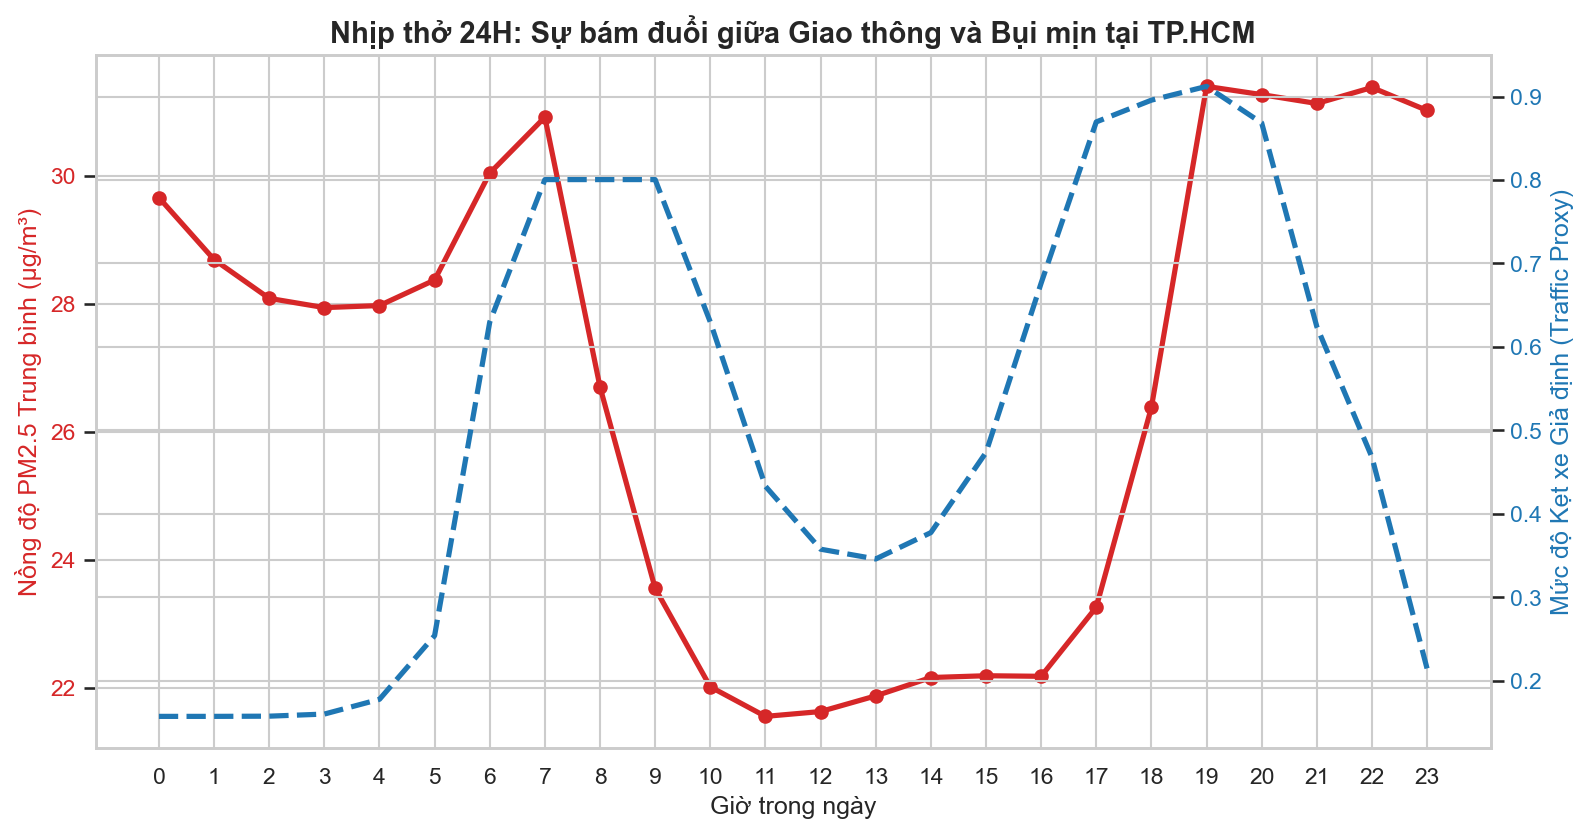

C:\Users\Tien Loi\AppData\Local\Temp\ipykernel_15840\1273800143.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_name', y='pm25', data=df, order=order, palette='Set2', showfliers=False)


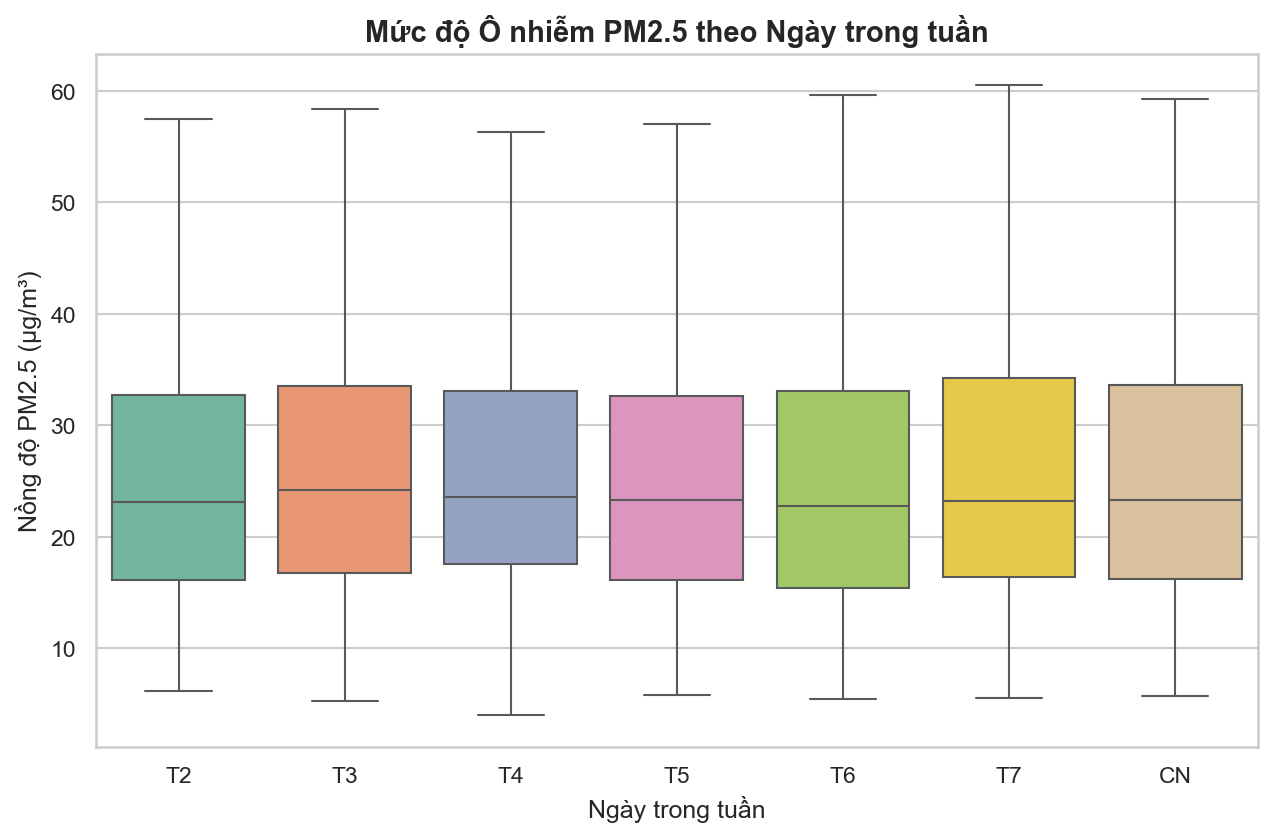

In [3]:
# BIỂU ĐỒ 3 & 4: PHÂN TÍCH CHU KỲ GIAO THÔNG VÀ THỜI GIAN
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập đường dẫn
PATH_INPUT = "../data/03_processed/pm25_features_ready.csv"
DIR_FIGURES = "../reports/figures/"
os.makedirs(DIR_FIGURES, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

print("Đang xử lý dữ liệu cho biểu đồ Chu kỳ...")

try:
    df = pd.read_csv(PATH_INPUT)
    # BIỂU ĐỒ 3: Nhịp 24H (PM2.5 vs Traffic Proxy)
    # Tính giá trị trung bình theo từng giờ trong ngày
    hourly_trend = df.groupby('hour')[['pm25', 'traffic_proxy']].mean().reset_index()

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Vẽ đường PM2.5 (Trục trái)
    color1 = 'tab:red'
    ax1.set_xlabel('Giờ trong ngày', fontsize=12)
    ax1.set_ylabel('Nồng độ PM2.5 Trung bình (µg/m³)', color=color1, fontsize=12)
    ax1.plot(hourly_trend['hour'], hourly_trend['pm25'], color=color1, marker='o', linewidth=2.5, label='PM2.5')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_xticks(range(0, 24))

    # Tạo trục phải (Twin axis) để vẽ Traffic Proxy
    ax2 = ax1.twinx()  
    color2 = 'tab:blue'
    ax2.set_ylabel('Mức độ Kẹt xe Giả định (Traffic Proxy)', color=color2, fontsize=12)
    ax2.plot(hourly_trend['hour'], hourly_trend['traffic_proxy'], color=color2, linestyle='--', linewidth=2.5, label='Kẹt xe')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('Nhịp thở 24H: Sự bám đuổi giữa Giao thông và Bụi mịn tại TP.HCM', fontsize=14, fontweight='bold')
    
    # Lưu ảnh 3
    path_fig3 = os.path.join(DIR_FIGURES, "03_diurnal_cycle.png")
    plt.savefig(path_fig3, bbox_inches='tight')
    plt.show()

    # BIỂU ĐỒ 4: Boxplot theo Ngày trong tuần
    plt.figure(figsize=(10, 6))
    
    # Đổi số thành chữ cho dễ nhìn trên biểu đồ
    day_mapping = {0: 'T2', 1: 'T3', 2: 'T4', 3: 'T5', 4: 'T6', 5: 'T7', 6: 'CN'}
    df['day_name'] = df['day_of_week'].map(day_mapping)
    
    # Sắp xếp lại thứ tự các ngày
    order = ['T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'CN']
    
    # Dùng boxplot nhưng bỏ bớt các điểm dị thường (outliers) quá cao để hộp dễ nhìn hơn
    sns.boxplot(x='day_name', y='pm25', data=df, order=order, palette='Set2', showfliers=False)
    
    plt.title('Mức độ Ô nhiễm PM2.5 theo Ngày trong tuần', fontsize=14, fontweight='bold')
    plt.xlabel('Ngày trong tuần')
    plt.ylabel('Nồng độ PM2.5 (µg/m³)')
    
    # Lưu ảnh 4
    path_fig4 = os.path.join(DIR_FIGURES, "04_weekly_boxplot.png")
    plt.savefig(path_fig4, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Lỗi: {e}")